
# **Initiate and Configure Spark**

---


In [ ]:
!pip3 install pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.9/316.9 MB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyspark: filename=pyspark-3.5.0-py2.py3-none-any.whl size=317425345 sha256=0fdf605c8c6bf5902f8b2568fa1f19486311c62577a01645070124076cb979db
  Stored in directory: /root/.cache/pip/wheels/41/4e/10/c2cf2467f71c678cfc8a6b9ac9241e5e44a01940da8fbb17fc
Successfully built pyspark


In [ ]:
# linking with Spark
import pandas as pds
import matplotlib.pyplot as pt
from os import truncate
from pyspark.sql import SparkSession
from pyspark.sql.functions import regexp_extract

#creating a sparksession
BigDataSession = SparkSession.builder.appName("WebLogSplit").getOrCreate()

# **Load Unstructured Data and Convert it to Spark DF**

---


In [ ]:
# Load the unstructrued data: (1) drag and drop data here or (2) use Google Drive
from google.colab import drive
drive.mount('/content/drive')

Weblog_df = BigDataSession.read.text("/content/drive/MyDrive/BIgdata/web.log")

Mounted at /content/drive


In [ ]:
# Convert the unstructrued data to Spark DF
regex_pattern=  r'(\S+) - - \[(\S+):\d+\] "(\w+) (\S+) (\S+)" (\d+) (\d+) (.*)$'

# Using regular expression pattern to extract the information
WEbLogs = Weblog_df.select(regexp_extract('value', regex_pattern, 1).alias('Host_making_the_request'),
                           regexp_extract('value', regex_pattern, 2).alias('Timestamp'),
                           regexp_extract('value', regex_pattern, 3).alias('HTTP_method'),
                           regexp_extract('value', regex_pattern, 4).alias('URL'),
                           regexp_extract('value', regex_pattern, 5).alias('HTTP_Version'),
                           regexp_extract('value', regex_pattern, 6).cast('integer').alias('HTTP_status_code'),
                           regexp_extract('value', regex_pattern, 7).cast('integer').alias('Bytes_in_the_reply'),
                           regexp_extract('value', regex_pattern, 8).alias('Message'))
# Show the structured DataFrame
WEbLogs.show(truncate = False)


+-----------------------+-----------------+-----------+---------------------------------------+------------+----------------+------------------+--------------------------------------------------------------+
|Host_making_the_request|Timestamp        |HTTP_method|URL                                    |HTTP_Version|HTTP_status_code|Bytes_in_the_reply|Message                                                       |
+-----------------------+-----------------+-----------+---------------------------------------+------------+----------------+------------------+--------------------------------------------------------------+
|88.211.105.115         |04/Mar/2022:14:17|POST       |/history/missions/                     |HTTP/2.0    |414             |12456             |Caution: System may require attention. Check logs for details.|
|144.6.49.142           |02/Sep/2022:15:16|POST       |/security/firewall/                    |HTTPS/1.0   |203             |97126             |Warning: Unusual behavio


# **Task 1: Spark SQL **

---



In [ ]:
#creating a tempview for the database and running the queries
WEbLogs.createOrReplaceTempView("LogView")
sqlDF = BigDataSession.sql("SELECT * FROM LogView")
sqlDF.show()

+-----------------------+-----------------+-----------+--------------------+------------+----------------+------------------+--------------------+
|Host_making_the_request|        Timestamp|HTTP_method|                 URL|HTTP_Version|HTTP_status_code|Bytes_in_the_reply|             Message|
+-----------------------+-----------------+-----------+--------------------+------------+----------------+------------------+--------------------+
|         88.211.105.115|04/Mar/2022:14:17|       POST|  /history/missions/|    HTTP/2.0|             414|             12456|Caution: System m...|
|           144.6.49.142|02/Sep/2022:15:16|       POST| /security/firewall/|   HTTPS/1.0|             203|             97126|Warning: Unusual ...|
|          231.70.64.145|19/Jul/2022:01:31|        PUT|/web-development/...|    HTTP/1.0|             201|             33093|Informational mes...|
|         219.42.234.172|08/Feb/2022:11:34|       POST|/networking/techn...|    HTTP/1.0|             415|            

In [ ]:
# Query 1 [finding the error rate for different status codes from the table]:
sqlDF = BigDataSession.sql("SELECT HTTP_status_code, COUNT(*) AS error_count FROM LogView WHERE HTTP_status_code NOT IN ('200', '304') GROUP BY HTTP_status_code;")
sqlDF.show()


+----------------+-----------+
|HTTP_status_code|error_count|
+----------------+-----------+
|             416|     214174|
|             205|     214455|
|             308|     214515|
|             500|     214527|
|             415|     214135|
|             202|     214738|
|             307|     213800|
|             404|     214584|
|             203|     214133|
|             414|     214705|
|             204|     213491|
|             201|     214586|
+----------------+-----------+



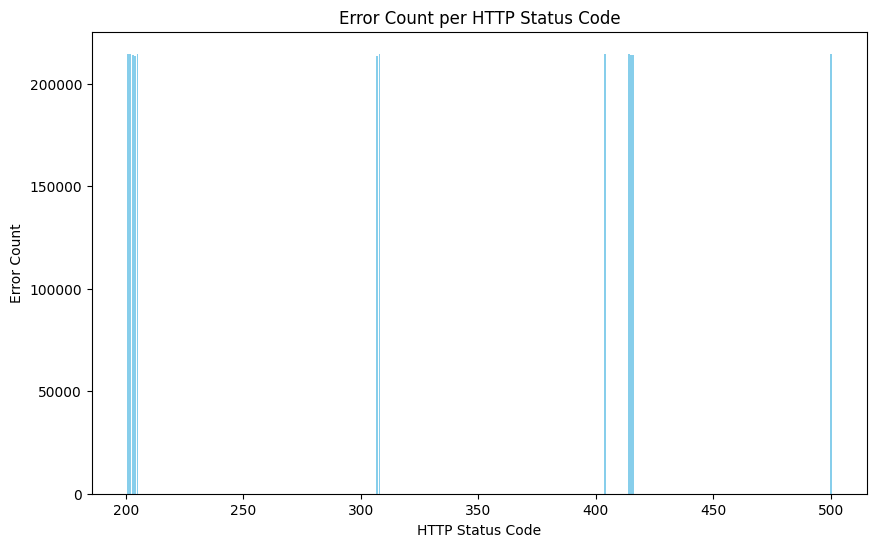

In [ ]:

# Convert Spark DataFrame to Pandas DataFrame
df_pandas = sqlDF.toPandas()

# Plotting
pt.figure(figsize=(10, 6))
pt.bar(df_pandas['HTTP_status_code'], df_pandas['error_count'], color='skyblue')
pt.xlabel('HTTP Status Code')
pt.ylabel('Error Count')
pt.title('Error Count per HTTP Status Code')
pt.show()


In [ ]:
# Query 2 [finding the top 10 IP addresses that have generated the most traffic from the above table]:
sqlDF1 = BigDataSession.sql("SELECT Host_making_the_request, COUNT(*) AS traffic FROM logView GROUP BY Host_making_the_request ORDER BY traffic DESC LIMIT 10; ")
sqlDF1.show()


+-----------------------+-------+
|Host_making_the_request|traffic|
+-----------------------+-------+
|         211.140.93.157|      2|
|          206.23.52.188|      2|
|           71.28.60.234|      2|
|          50.100.60.144|      2|
|           77.32.147.84|      2|
|          215.221.36.33|      2|
|          110.174.52.40|      2|
|            47.68.29.34|      2|
|          22.16.163.201|      2|
|          234.232.43.71|      2|
+-----------------------+-------+



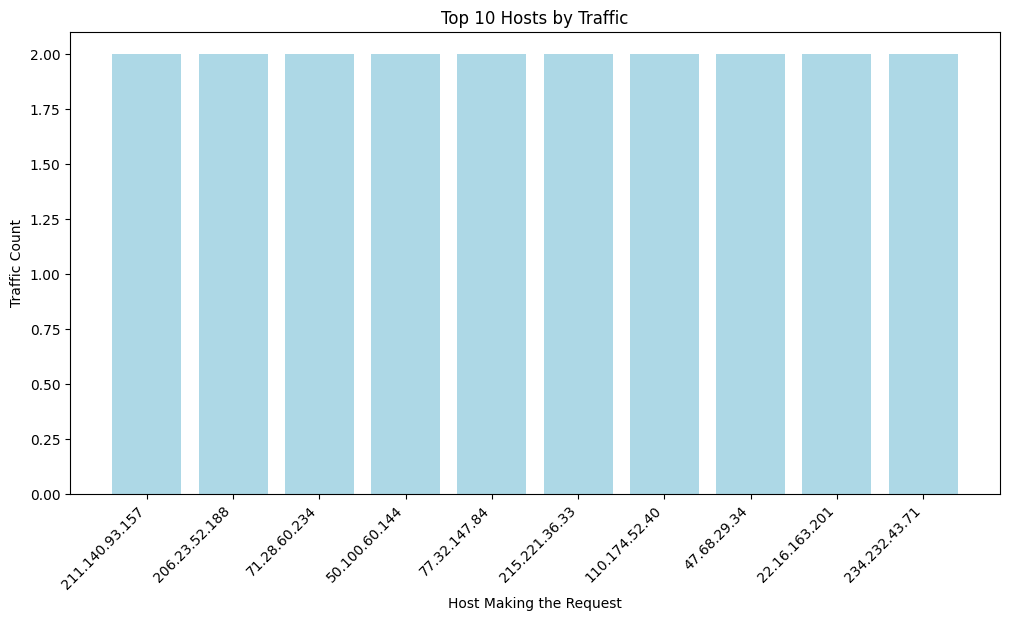

In [ ]:

# Convert Spark DataFrame to Pandas DataFrame
df_pandas1 = sqlDF1.toPandas()

# Plotting
pt.figure(figsize=(12, 6))
pt.bar(df_pandas1['Host_making_the_request'], df_pandas1['traffic'], color='lightblue')
pt.xlabel('Host Making the Request')
pt.ylabel('Traffic Count')
pt.title('Top 10 Hosts by Traffic')
pt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility
pt.show()


In [ ]:
# Query 1 [receiving average, maximum and minimum content_size from the above table using avg,max min functions]:
sqlDF2 = BigDataSession.sql("SELECT AVG(Bytes_in_the_reply) AS avg_content_size, MAX(Bytes_in_the_reply) AS max_content_size, MIN(Bytes_in_the_reply) AS min_content_size FROM LogView;")
sqlDF2.show()


+------------------+----------------+----------------+
|  avg_content_size|max_content_size|min_content_size|
+------------------+----------------+----------------+
|50499.150722666665|          100000|            1000|
+------------------+----------------+----------------+



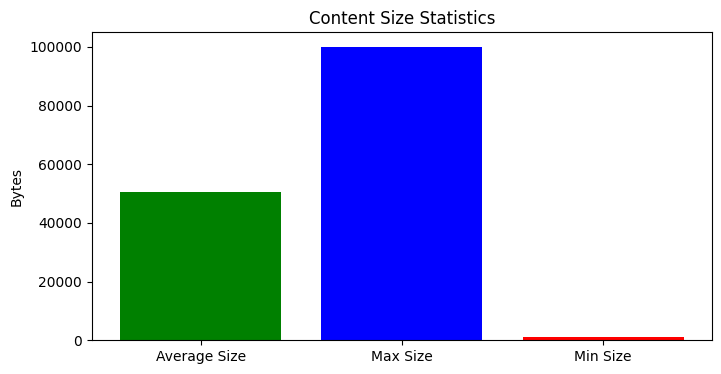

In [ ]:

# Convert Spark DataFrame to Pandas DataFrame
df_pandas2 = sqlDF2.toPandas()

# Extract values
avg_size = df_pandas2['avg_content_size'].iloc[0]
max_size = df_pandas2['max_content_size'].iloc[0]
min_size = df_pandas2['min_content_size'].iloc[0]

# Plotting
fig, ax = pt.subplots(figsize=(8, 4))
ax.bar(['Average Size', 'Max Size', 'Min Size'], [avg_size, max_size, min_size], color=['green', 'Blue', 'red'])
ax.set_ylabel('Bytes')
ax.set_title('Content Size Statistics')
pt.show()


In [ ]:

# Query 2 [ identify the top 10 hits of url in the table ]:
sqlDF3 = BigDataSession.sql("SELECT URL, COUNT(*) AS hits FROM LogView GROUP BY URL ORDER BY hits DESC LIMIT 10;")
sqlDF3.show()


+--------------------+-----+
|                 URL| hits|
+--------------------+-----+
|/data-analysis/ap...|25440|
|     /software/data/|25382|
|/web-development/...|25343|
| /history/countdown/|25338|
|/software/technol...|25327|
|/security/technol...|25307|
|/networking/deep-...|25300|
|/networking/firew...|25249|
|/security/countdown/|25239|
|    /history/apollo/|25238|
+--------------------+-----+



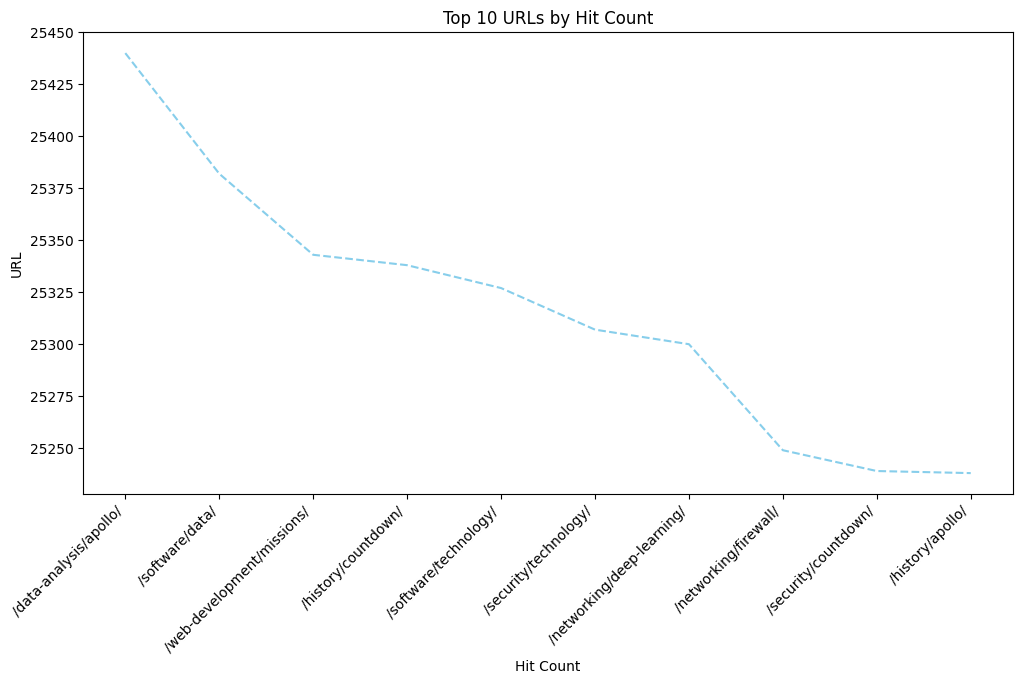

In [ ]:

# Convert Spark DataFrame to Pandas DataFrame
df_pandas3 = sqlDF3.toPandas()

# Plotting
pt.figure(figsize=(12, 6))
pt.plot(df_pandas3['URL'], df_pandas3['hits'], linestyle='--',color='skyblue')
pt.xlabel('Hit Count')
pt.ylabel('URL')
pt.title('Top 10 URLs by Hit Count')
pt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility
pt.show()


In [ ]:

# Query 1 [Top 10 IP addresses with the largest content sizes from the table using sum,group by,order by, desc and limit functions ]:
sqlDF4 = BigDataSession.sql("SELECT Host_making_the_request, SUM(Bytes_in_the_reply) AS total_size FROM LogView GROUP BY Host_making_the_request ORDER BY total_size DESC LIMIT 10;")
sqlDF4.show()


+-----------------------+----------+
|Host_making_the_request|total_size|
+-----------------------+----------+
|          34.162.74.219|    197146|
|          116.76.146.27|    194039|
|          81.113.19.213|    192657|
|          33.143.78.210|    191196|
|           95.11.120.39|    188705|
|            8.161.96.53|    188401|
|         84.239.126.221|    188112|
|         163.196.179.13|    188020|
|          187.64.67.180|    187971|
|         160.141.94.216|    185424|
+-----------------------+----------+



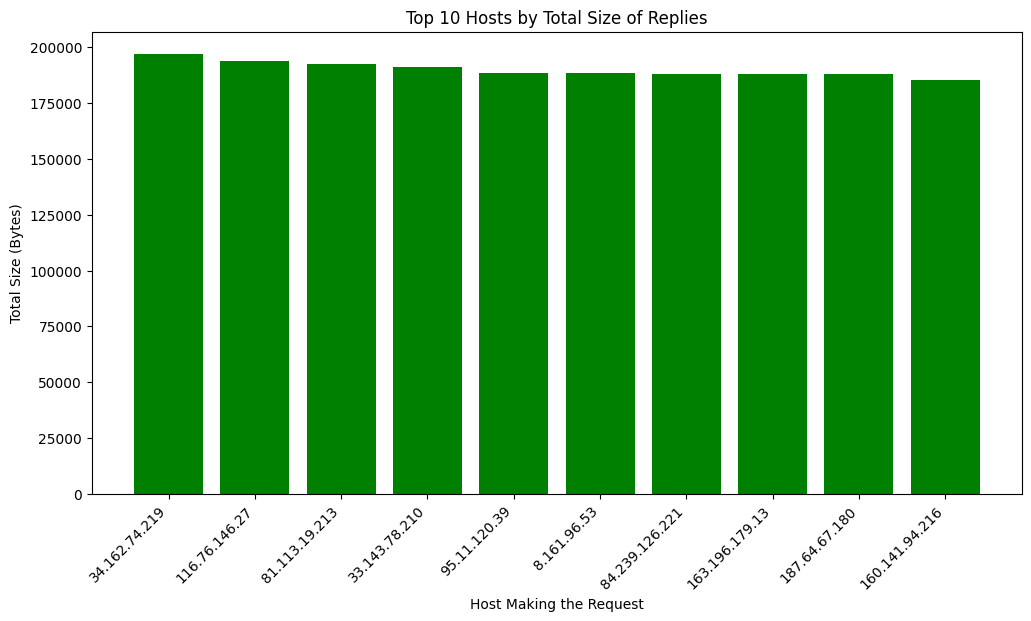

In [ ]:

# Convert Spark DataFrame to Pandas DataFrame
df_pandas4 = sqlDF4.toPandas()

# Plotting
pt.figure(figsize=(12, 6))
pt.bar(df_pandas4['Host_making_the_request'], df_pandas4['total_size'], color='green')
pt.xlabel('Host Making the Request')
pt.ylabel('Total Size (Bytes)')
pt.title('Top 10 Hosts by Total Size of Replies')
pt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility
pt.show()


In [ ]:

# Query 2 [Find the top 10 most occured URLs from the above table using count,group by, order by and desc for g3tting them in descending values and LIMIT-FOR limiting the values shown to 10]:
sqlDF5 = BigDataSession.sql("SELECT URL,COUNT(*) AS url_count FROM LogView GROUP BY URL ORDER BY url_count DESC LIMIT 10")
sqlDF5.show()

+--------------------+---------+
|                 URL|url_count|
+--------------------+---------+
|/data-analysis/ap...|    25440|
|     /software/data/|    25382|
|/web-development/...|    25343|
| /history/countdown/|    25338|
|/software/technol...|    25327|
|/security/technol...|    25307|
|/networking/deep-...|    25300|
|/networking/firew...|    25249|
|/security/countdown/|    25239|
|    /history/apollo/|    25238|
+--------------------+---------+



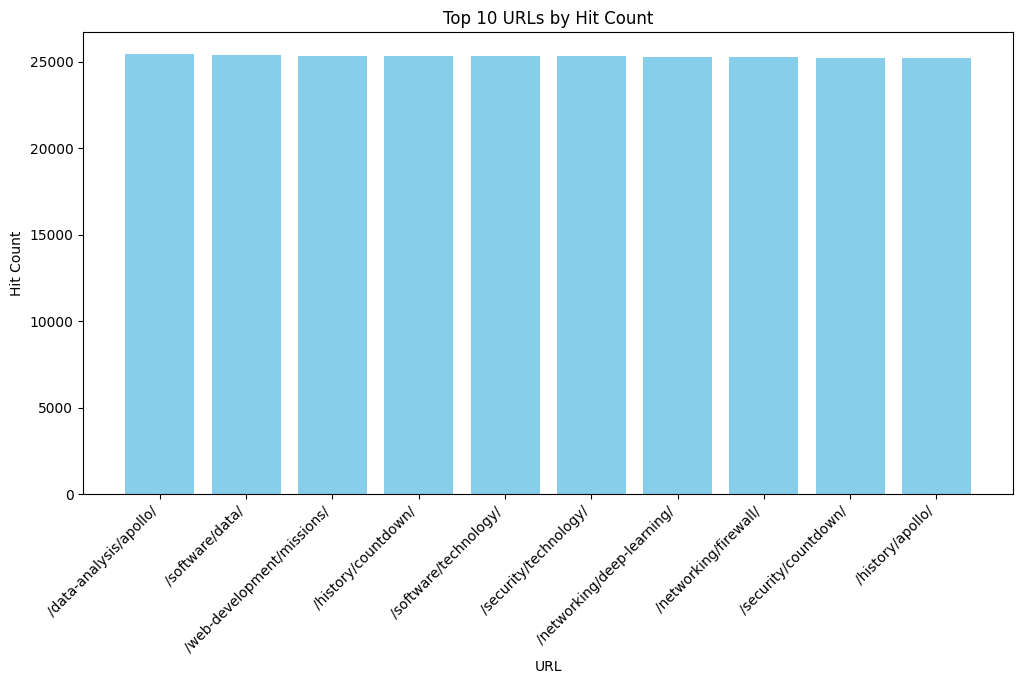

In [ ]:

# Convert Spark DataFrame to Pandas DataFrame
df_pandas5 = sqlDF5.toPandas()

# Plotting
pt.figure(figsize=(12, 6))
pt.bar(df_pandas5['URL'], df_pandas5['url_count'], color='skyblue')
pt.xlabel('URL')
pt.ylabel('Hit Count')
pt.title('Top 10 URLs by Hit Count')
pt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility
pt.show()


In [ ]:

# Query 1 [ Number of unique URLs  for each status in the table using count,distinct and group by ]:
sqlDF6 = BigDataSession.sql("SELECT HTTP_status_code, COUNT(DISTINCT url) AS unique_urls_count FROM LogView GROUP BY HTTP_status_code;")
sqlDF6.show()


+----------------+-----------------+
|HTTP_status_code|unique_urls_count|
+----------------+-----------------+
|             416|              120|
|             205|              120|
|             308|              120|
|             500|              120|
|             415|              120|
|             202|              120|
|             307|              120|
|             404|              120|
|             203|              120|
|             414|              120|
|             200|              120|
|             304|              120|
|             204|              120|
|             201|              120|
+----------------+-----------------+



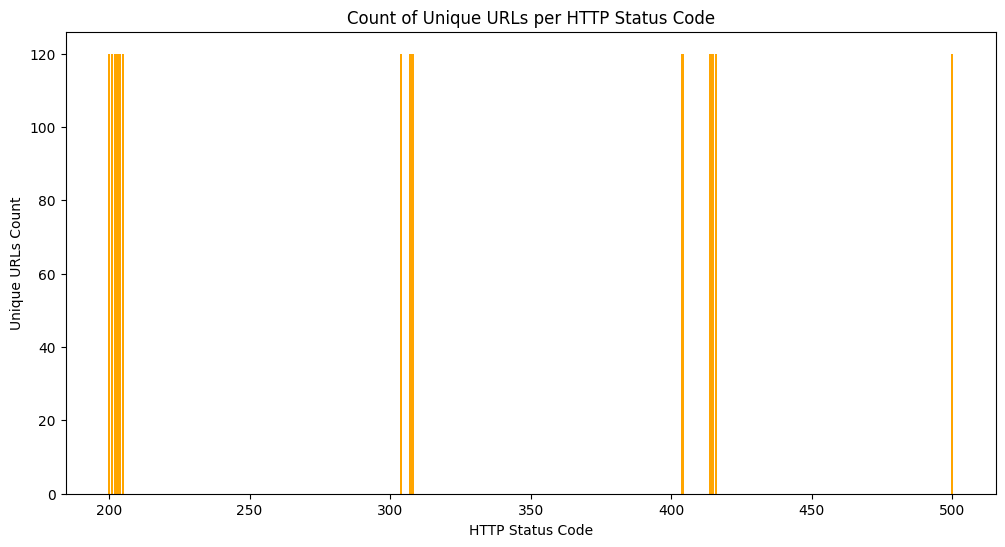

In [ ]:

# Convert Spark DataFrame to Pandas DataFrame
df_pandas6 = sqlDF6.toPandas()

# Plotting
pt.figure(figsize=(12, 6))
pt.bar(df_pandas6['HTTP_status_code'], df_pandas6['unique_urls_count'], color='orange')
pt.xlabel('HTTP Status Code')
pt.ylabel('Unique URLs Count')
pt.title('Count of Unique URLs per HTTP Status Code')
pt.show()


In [ ]:

# Query 2 [List the number of methods based on the Bytes_in_the_reply and the HTTPS/1.0 HTTP_version using count and group by]:
sqlDF = BigDataSession.sql("SELECT HTTP_method, count(*) from LogView where Bytes_in_the_reply>1000 and HTTP_version='HTTPS/1.0' GROUP BY HTTP_method")
sqlDF.show()


+-----------+--------+
|HTTP_method|count(1)|
+-----------+--------+
|       POST|  333787|
|        PUT|  332120|
|        GET|  333431|
+-----------+--------+



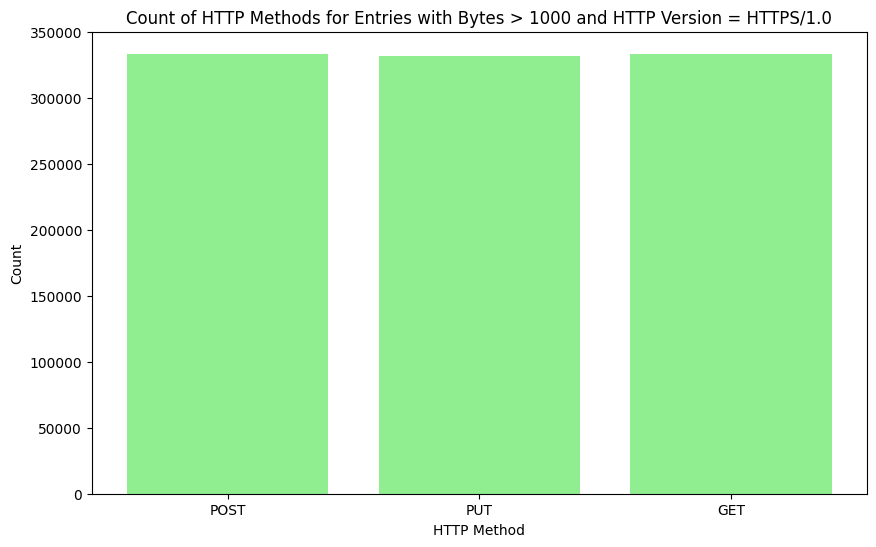

In [ ]:

# Convert Spark DataFrame to Pandas DataFrame
df_pandas = sqlDF.toPandas()

# Plotting
pt.figure(figsize=(10, 6))
pt.bar(df_pandas['HTTP_method'], df_pandas['count(1)'], color='lightgreen')
pt.xlabel('HTTP Method')
pt.ylabel('Count')
pt.title('Count of HTTP Methods for Entries with Bytes > 1000 and HTTP Version = HTTPS/1.0')
pt.show()


In [ ]:
sqlDF = BigDataSession.sql("select HTTP_method,SUM(case when HTTP_version='HTTP/2.0' and message like '%Warning%' then 1 else 0 end)as subcount from LogView where HTTP_method is not null group by HTTP_method")
sqlDF.show()

+-----------+--------+
|HTTP_method|subcount|
+-----------+--------+
|       POST|   37077|
|        PUT|   37028|
|        GET|   36621|
+-----------+--------+



<Axes: xlabel='HTTP_method'>

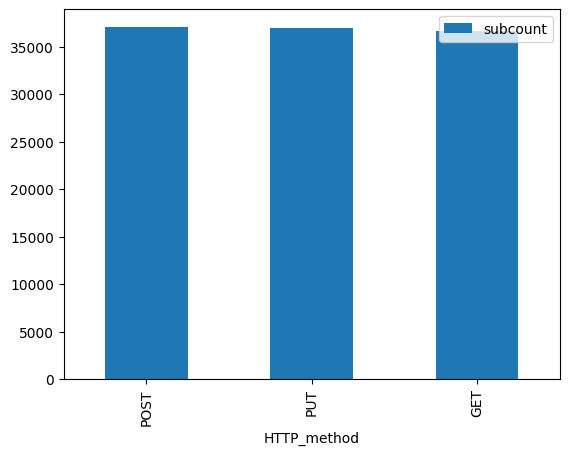

In [ ]:
df6=sqlDF.toPandas()
df6.sort_values(by='subcount',ascending=False).plot(x='HTTP_method', y='subcount', kind = 'bar')

In [ ]:
sqlDF = BigDataSession.sql("SELECT URL,COUNT(URL) AS count FROM LogView WHERE URL IN (SELECT URL FROM LogView WHERE message LIKE '%Warning%' AND HTTP_status_Code = 404) GROUP BY URL")
sqlDF.show()

+--------------------+-----+
|                 URL|count|
+--------------------+-----+
|/web-development/...|24648|
|   /security/apollo/|24996|
|      /history/data/|25186|
|/history/technology/|25175|
|/data-analysis/aw...|24686|
|/cloud-computing/...|25093|
|/shuttle/frontend...|24836|
|    /history/launch/|24965|
|/software/apollo-11/|25096|
|/data-analysis/fr...|25174|
|/networking/front...|25124|
|   /security/launch/|24873|
|/machine-learning...|25188|
|/security/countdown/|25239|
|     /security/data/|24812|
|/networking/count...|25153|
|/web-development/...|24877|
|/networking/aws-c...|24825|
|  /shuttle/missions/|24922|
|      /shuttle/data/|24984|
+--------------------+-----+
only showing top 20 rows



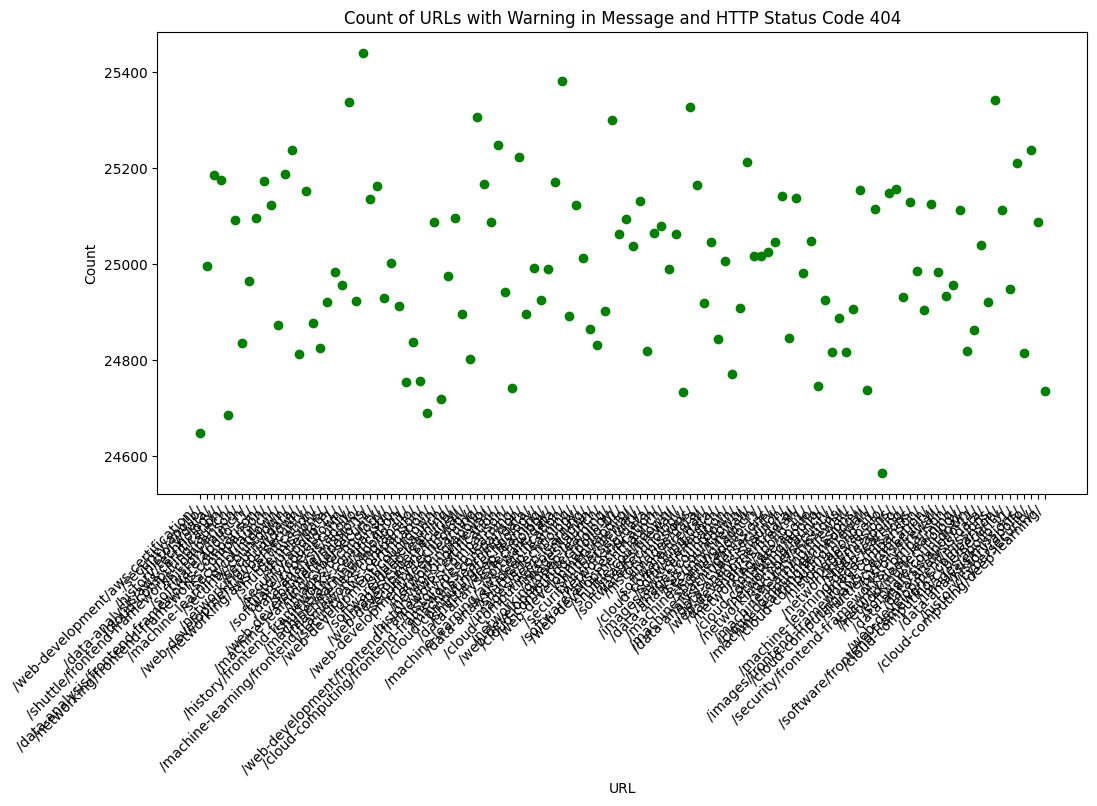

In [ ]:

# Convert Spark DataFrame to Pandas DataFrame
df_pandas = sqlDF.toPandas()

# Plotting
pt.figure(figsize=(12, 6))
pt.scatter(df_pandas['URL'], df_pandas['count'], color='green')
pt.xlabel('URL')
pt.ylabel('Count')
pt.title('Count of URLs with Warning in Message and HTTP Status Code 404')
pt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility
pt.show()


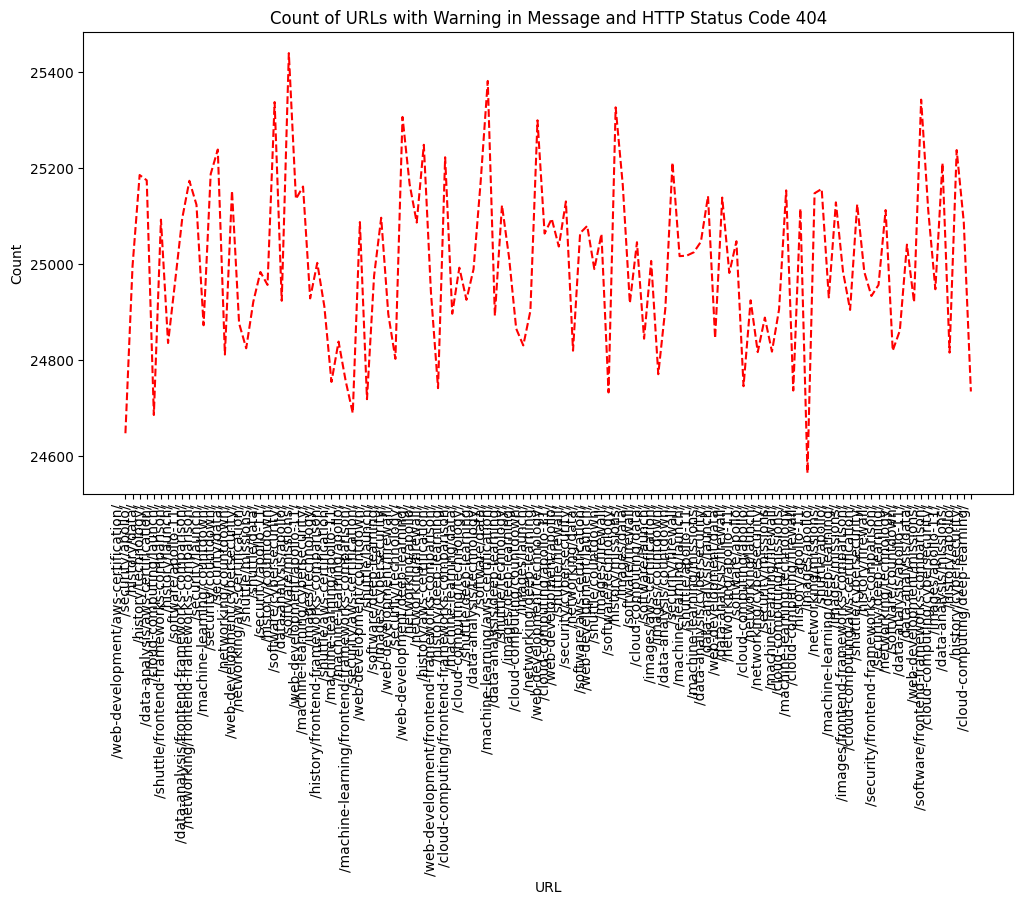

In [ ]:

# Convert Spark DataFrame to Pandas DataFrame
df_pandas = sqlDF.toPandas()

# Plotting
pt.figure(figsize=(12, 6))
pt.plot(df_pandas['URL'], df_pandas['count'], linestyle='--', color='red')
#pt.scatter(df_pandas['URL'], df_pandas['count'], color='green')
pt.xlabel('URL')
pt.ylabel('Count')
pt.title('Count of URLs with Warning in Message and HTTP Status Code 404')
pt.xticks(rotation=90, ha='right')  # Rotate x-axis labels for better visibility
pt.show()



# **Task 2 - Spark RDD **

---


In [ ]:
BigDataSession.stop()

In [ ]:
from pyspark import SparkContext,SparkConf
from pyspark.sql import SparkSession

#initialise spark
conf=SparkConf()
conf.set("spark.app.name","RDDlog")
conf.set("spark.master","local[*]")
sc=SparkContext(conf=conf)

#create sparksession
spark=SparkSession.builder.appName("RDDLogs").getOrCreate()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

rdd_logs=sc.textFile('/content/drive/MyDrive/BIgdata/web.log')
rdd_logs.take(10)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['88.211.105.115 - - [04/Mar/2022:14:17:48] "POST /history/missions/ HTTP/2.0" 414 12456 Caution: System may require attention. Check logs for details.',
 '144.6.49.142 - - [02/Sep/2022:15:16:00] "POST /security/firewall/ HTTPS/1.0" 203 97126 Warning: Unusual behavior detected. Investigate further.',
 '231.70.64.145 - - [19/Jul/2022:01:31:31] "PUT /web-development/countdown/ HTTP/1.0" 201 33093 Informational message. No action required.',
 '219.42.234.172 - - [08/Feb/2022:11:34:57] "POST /networking/technology/ HTTP/1.0" 415 68827 Debug: Detailed system state information.',
 '183.173.185.94 - - [29/Aug/2023:03:07:11] "GET /security/firewall/ HTTP/2.0" 205 30374 Warning: Unusual behavior detected. Investigate further.',
 '164.12.8.113 - - [22/May/2023:09:48:25] "GET /web-development/technology/ HTTP/1.0" 200 14633 Informational message. No action required.',
 '110.98.7.240 - - [22/Jan/2023:09:55:54] "PUT /history/apollo/ HTTP/2.0" 204 63819 Debug: Detailed system state information.',
 '

In [ ]:

# #no of times the same url is repeated
top_url = rdd_logs.map(lambda line: (line.split()[5], 1)) \
                        .reduceByKey(lambda a, b: a + b) \
                        .takeOrdered(5, key=lambda x: -x[1])

top_url

[('/data-analysis/apollo/', 25440),
 ('/software/data/', 25382),
 ('/web-development/missions/', 25343),
 ('/history/countdown/', 25338),
 ('/software/technology/', 25327)]

In [ ]:

# name of te url and the percentage of occurances in the file:
from operator import add

total_requests = rdd_logs.count()
url_counts = rdd_logs.map(lambda line: (line.split()[5][1:-1], 1)) \
                        .reduceByKey(add) \
                        .map(lambda x: (x[0], (x[1] / total_requests) * 100))

url_percentage = url_counts.takeOrdered(10, key=lambda x: -x[1])

for method, percentage in url_percentage:
    print(f"Name of URL: {method}, Percentage: {percentage}%")


Name of URL: data-analysis/apollo, Percentage: 0.848%
Name of URL: software/data, Percentage: 0.8460666666666666%
Name of URL: web-development/missions, Percentage: 0.8447666666666666%
Name of URL: history/countdown, Percentage: 0.8446%
Name of URL: software/technology, Percentage: 0.8442333333333333%
Name of URL: security/technology, Percentage: 0.8435666666666666%
Name of URL: networking/deep-learning, Percentage: 0.8433333333333333%
Name of URL: networking/firewall, Percentage: 0.8416333333333333%
Name of URL: security/countdown, Percentage: 0.8413%
Name of URL: history/apollo, Percentage: 0.8412666666666667%


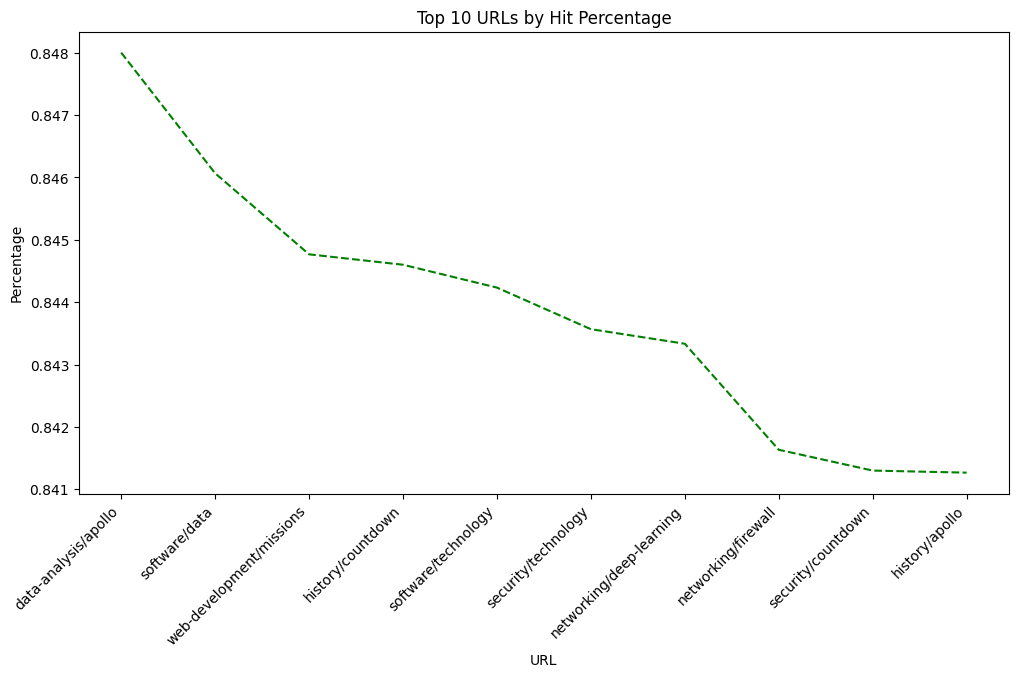

In [ ]:
import matplotlib.pyplot as plt



# Extract data for plotting
urls, percentages = zip(*url_percentage)

# Plotting
plt.figure(figsize=(12, 6))

plt.plot(urls, percentages,linestyle='--', color='green')
plt.xlabel('URL')
plt.ylabel('Percentage')
plt.title('Top 10 URLs by Hit Percentage')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility
plt.show()


In [ ]:

# Day with highest number of requests
from operator import add

day_counts = rdd_logs.map(lambda line: (line.split()[3].split(":")[0], 1)) \
                   .reduceByKey(add)
max_day = day_counts.takeOrdered(1, key=lambda x: -x[1])
print(f"Day with the highest number of requests: {max_day[0][0]}, Count: {max_day[0][1]}")


Day with the highest number of requests: [09/Sep/2022, Count: 4604


In [ ]:

# unique ip addresses in the log file
ip_counts = rdd_logs.map(lambda line: (line.split()[0], 1)) \
                   .reduceByKey(add)
unique_ips = ip_counts.count()
print(f"Number of unique IP addresses: {unique_ips}")

Number of unique IP addresses: 2998934


In [ ]:

# #no of times the same ip address or host address is repeated
ip_level = rdd_logs.map(lambda line: (line.split()[0],1)) \
                              .reduceByKey(lambda x, y: x + y) \
                              .takeOrdered(7,key=lambda x:-x[1])
ip_level


[('61.203.220.155', 2),
 ('225.2.68.42', 2),
 ('189.15.120.110', 2),
 ('190.63.218.54', 2),
 ('18.133.225.189', 2),
 ('94.197.23.111', 2),
 ('221.28.12.178', 2)]

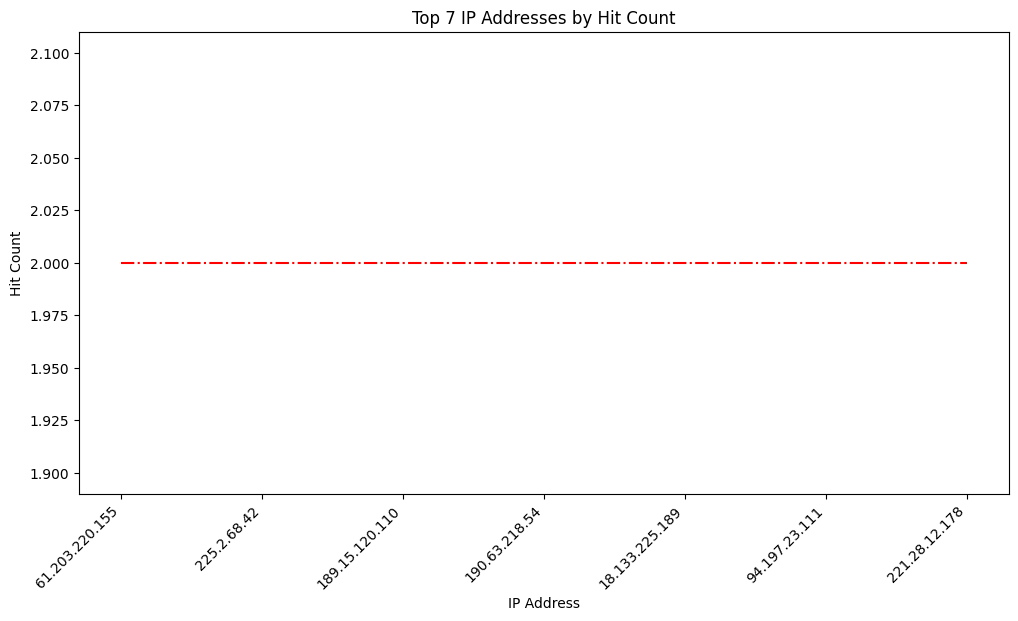

In [ ]:
# Extract data for plotting
ips, hit_counts = zip(*ip_level)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(ips, hit_counts,linestyle="-.", color='red')
plt.xlabel('IP Address')
plt.ylabel('Hit Count')
plt.title('Top 7 IP Addresses by Hit Count')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility
plt.show()




In [ ]:

# Extract referrers from log entries
referrers = rdd_logs.map(lambda line: line.split()[9]) \
                    .filter(lambda referrer: referrer != "").distinct().count()

print(f'number of unique referrers in the logfile are={referrers}')



number of unique referrers in the logfile are=9


In [ ]:

#Identifying log entries with the highest variability in message length:

variability_entries = rdd_logs.map(lambda line: (line.split()[9], len(line))) \
                            .combineByKey(lambda value: (value, value, 1),
                                          lambda x, value: (min(x[0], value), max(x[1], value), x[2] + 1),
                                          lambda x, y: (min(x[0], y[0]), max(x[1], y[1]), x[2] + y[2])) \
                            .mapValues(lambda x: (x[1] - x[0]) / x[2]) \
                            .takeOrdered(5, key=lambda x: -x[1])
variability_entries

[('Informational', 0.00013509821640332522),
 ('Debugging', 0.00013245511577781257),
 ('Caution:', 0.00013216983824214116),
 ('Warning:', 0.00013206669368030855),
 ('Debug:', 0.00013197795968073332)]

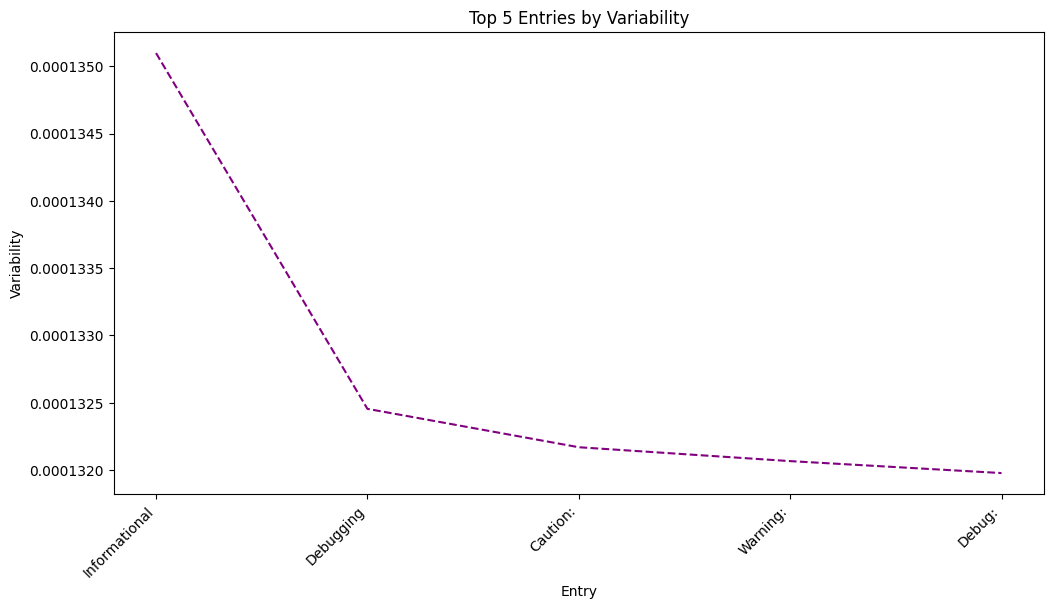

In [ ]:

# Extract data for plotting
entries, variabilities = zip(*variability_entries)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(entries, variabilities,linestyle="--", color='purple')
plt.xlabel('Entry')
plt.ylabel('Variability')
plt.title('Top 5 Entries by Variability')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility
plt.show()



In [ ]:

#no of times the same timestamp is repeated
timestamps = rdd_logs.map(lambda line: (line.split()[3],1)) \
                              .reduceByKey(lambda x, y: x + y) \
                              .takeOrdered(8,key=lambda x:-x[1])
timestamps


[('[15/Apr/2023:21:54:16]', 4),
 ('[25/Oct/2022:09:12:33]', 4),
 ('[02/Oct/2022:07:51:49]', 4),
 ('[24/Aug/2022:15:55:48]', 4),
 ('[02/Oct/2023:21:52:25]', 4),
 ('[28/Jan/2023:03:46:44]', 4),
 ('[19/Aug/2023:13:55:32]', 4),
 ('[20/Jul/2023:17:15:09]', 4)]

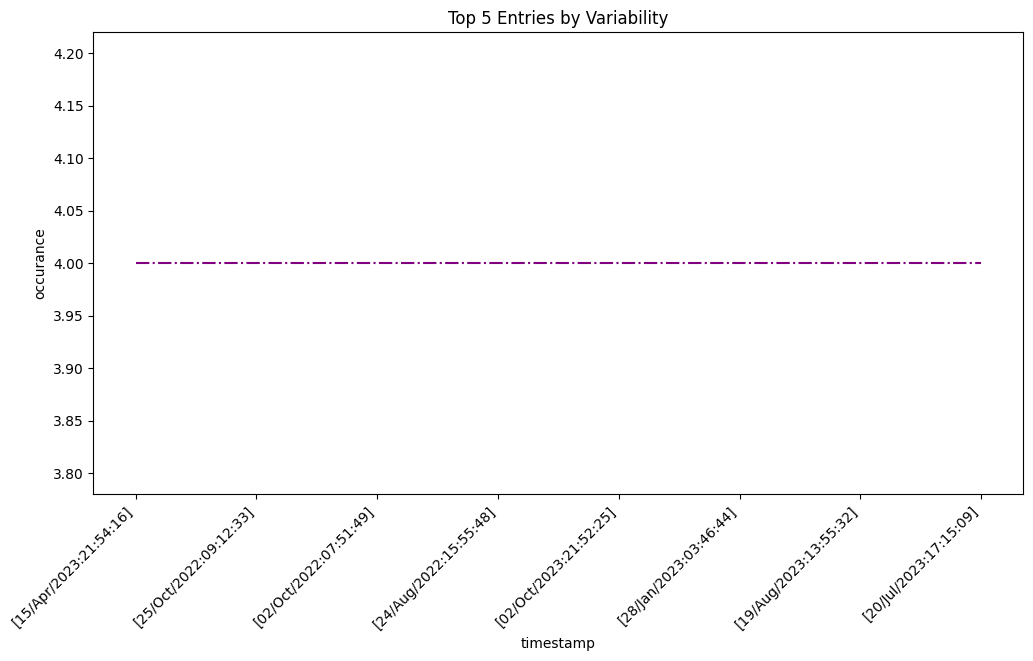

In [ ]:

# Extract data for plotting
timestamps, hit_counts = zip(*timestamps)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(timestamps,hit_counts ,linestyle="-.", color='purple')
plt.xlabel('timestamp')
plt.ylabel('occurance')
plt.title('Top 5 Entries by Variability')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility
plt.show()




In [ ]:


#entropy of log files
from math import log2

total_entries = rdd_logs.count()
level_entropy = rdd_logs.map(lambda line: (line.split()[9], 1)) \
                       .reduceByKey(lambda x, y: x + y) \
                       .map(lambda x: (x[0], x[1] / total_entries)) \
                       .map(lambda x: (x[0], -x[1] * log2(x[1]))) \
                       .reduceByKey(lambda x, y: x + y)
level_entropy.count()

9

In [ ]:

# analysis 3 and result using RDD operators:
day_with_most_ips = rdd_logs.map(lambda line: (line.split()[3].split(":")[0], line.split()[0])) \
                           .distinct() \
                           .map(lambda x: (x[0], 1)) \
                           .reduceByKey(lambda x, y: x + y) \
                           .max(key=lambda x: x[1])
day_with_most_ips


('[09/Sep/2022', 4604)

In [ ]:

# #no of times the same HTTP_version is repeated
top_bytes = rdd_logs.map(lambda line: (line.split()[6], 1)) \
                        .reduceByKey(lambda a, b: a + b) \
                        .takeOrdered(12, key=lambda x: -x[1])

top_bytes


[('HTTP/2.0"', 1000568), ('HTTP/1.0"', 1000084), ('HTTPS/1.0"', 999348)]

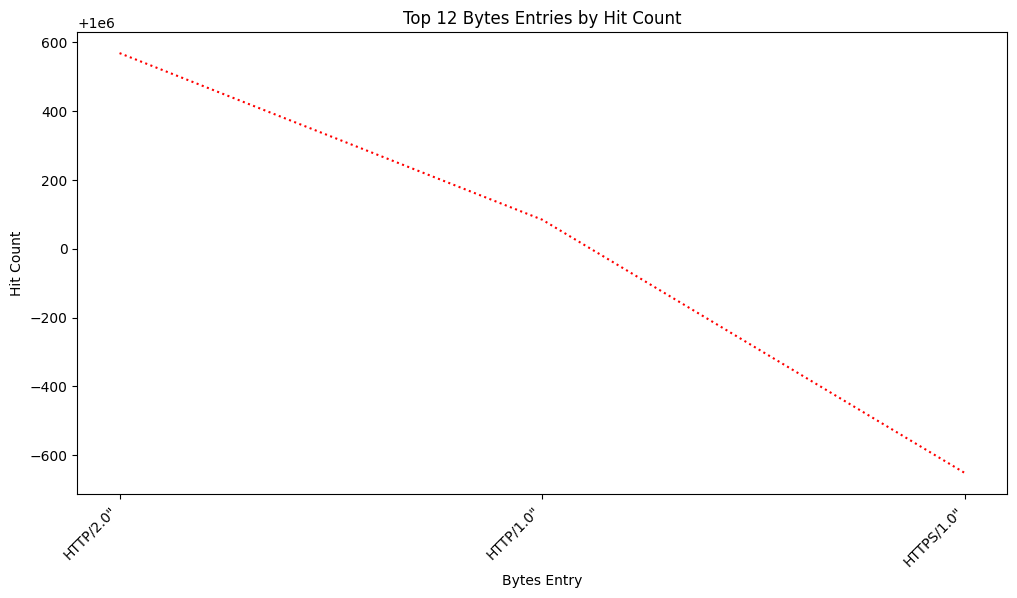

In [ ]:

# Extract data for plotting
bytes_entries, hit_counts = zip(*top_bytes)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(bytes_entries, hit_counts,linestyle=":", color='red')
plt.xlabel('Bytes Entry')
plt.ylabel('Hit Count')
plt.title('Top 12 Bytes Entries by Hit Count')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility
plt.show()


In [ ]:

#log entries with status code starting with "2"
client_error_logs = rdd_logs.filter(lambda line: line.split()[7].startswith("2")) \
                            .map(lambda log_entry: (log_entry, 1)) \
                            .reduceByKey(lambda x, y: x + y) \
                            .takeOrdered(10, key=lambda x: -x[1])

# Display the results
for log_entry, count in client_error_logs:
    print(f"Log Entry: {log_entry}, Count: {count}")



Log Entry: 12.33.251.59 - - [15/Aug/2022:15:59:37] "GET /web-development/data/ HTTP/2.0" 203 37029 Warning: Unusual behavior detected. Investigate further., Count: 1
Log Entry: 82.88.196.45 - - [02/Jun/2023:17:00:36] "PUT /history/apollo-11/ HTTPS/1.0" 205 6918 Debug: Detailed system state information., Count: 1
Log Entry: 56.100.82.151 - - [04/Dec/2022:01:26:00] "PUT /networking/missions/ HTTP/2.0" 203 90781 FYI: System operating within normal parameters., Count: 1
Log Entry: 183.124.82.211 - - [13/Aug/2023:01:11:29] "GET /networking/missions/ HTTPS/1.0" 201 80616 Informational message. No action required., Count: 1
Log Entry: 73.149.11.190 - - [23/Aug/2023:05:19:48] "POST /networking/aws-certification/ HTTPS/1.0" 204 22847 Update: Routine status report. All systems functioning., Count: 1
Log Entry: 53.211.7.217 - - [10/Feb/2022:22:22:45] "POST /history/firewall/ HTTP/1.0" 204 30569 Potential issue detected. Please review and address., Count: 1
Log Entry: 226.204.216.96 - - [10/Jun/20

In [ ]:

# Determine the percentage of bytes size between 12000 and 12400.

# Extract payload sizes from log entries
payload_sizes = rdd_logs.map(lambda line: int(line.split()[8]))

# Count the number of  bytes size between 12000 and 12400
bytes_count = payload_sizes.filter(lambda size: 12000 <= size <= 12400).count()

# Count the total number of requests
total_requests = payload_sizes.count()

# Calculate the percentage
percentage = (bytes_count / total_requests) * 100 if total_requests > 0 else 0

# Display the result
print(f"Percentage of byte Size Between 12000 bytes and 12400 KB: {percentage}%")




Percentage of byte Size Between 12000 bytes and 12400 KB: 0.39723333333333327%


# **Convert ipynb to HTML for Turnitin submission [5 marks]**

---



In [ ]:
# install nbconvert
#!pip3 install nbconvert


# convert ipynb to html
# file name: "119_CN7031.ipynb
!jupyter nbconvert --to html 119_CN7031.ipynb

[NbConvertApp] Converting notebook 119_CN7031.ipynb to html
[NbConvertApp] Writing 2369889 bytes to 119_CN7031.html
